# Analyse Exploratoire

In [73]:
%pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Import des modules

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

### Analyse Exploratoire

In [75]:
building_consumption = pd.read_csv("2016_Building_Energy_Benchmarking.csv")
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [76]:
# 1. On définit les types d'habitation à supprimer
types_habitation = ['Multifamily LR (1-4)', 'Multifamily MR (5-9)', 'Multifamily HR (10+)']

# 2. On filtre : on ne garde que ce qui n'est PAS dans la liste ci-dessus
# Le signe ~ veut dire "le contraire de"
building_consumption = building_consumption[~building_consumption['BuildingType'].isin(types_habitation)]

# 3. On vérifie combien de bâtiments il nous reste
print(f"Nombre de bâtiments restants : {len(building_consumption)}")

# 4. On affiche les infos sur les colonnes
building_consumption.info()

Nombre de bâtiments restants : 1668
<class 'pandas.DataFrame'>
Index: 1668 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1668 non-null   int64  
 1   DataYear                         1668 non-null   int64  
 2   BuildingType                     1668 non-null   str    
 3   PrimaryPropertyType              1668 non-null   str    
 4   PropertyName                     1668 non-null   str    
 5   Address                          1668 non-null   str    
 6   City                             1668 non-null   str    
 7   State                            1668 non-null   str    
 8   ZipCode                          1652 non-null   float64
 9   TaxParcelIdentificationNumber    1668 non-null   str    
 10  CouncilDistrictCode              1668 non-null   int64  
 11  Neighborhood                     1668 non-null   str    
 12  

In [77]:
# On regarde les statistiques principales des colonnes numériques
building_consumption.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,1668.000000,1668.0,1652.000000,1668.000000,1668.000000,1668.000000,1668.000000,1666.000000,1668.000000,1.668000e+03,...,1.666000e+03,1.665000e+03,1.666000e+03,1.666000e+03,1.666000e+03,1.666000e+03,1.666000e+03,0.0,1666.000000,1666.000000
mean,16336.346523,2016.0,98116.819613,4.356715,47.616054,-122.332908,1961.913669,1.168667,4.121103,1.188427e+05,...,8.437933e+06,8.064790e+06,5.125726e+05,1.712630e+06,5.843493e+06,1.970845e+04,1.970845e+06,NaN,184.973301,1.607845
std,13835.292512,0.0,18.430353,2.191048,0.048168,0.024580,32.741755,2.931409,6.563407,2.973622e+05,...,3.024380e+07,2.203878e+07,5.513944e+06,6.095172e+06,2.079673e+07,9.370814e+04,9.370814e+06,NaN,751.976001,2.336882
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.411820,1900.000000,0.000000,0.000000,1.128500e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,582.750000,2016.0,98105.000000,2.000000,47.585458,-122.343280,1930.000000,1.000000,1.000000,2.947775e+04,...,1.229291e+06,1.294615e+06,0.000000e+00,2.114083e+05,7.213255e+05,0.000000e+00,0.000000e+00,NaN,19.967500,0.350000
50%,21143.500000,2016.0,98109.000000,4.000000,47.612340,-122.332935,1965.000000,1.000000,2.000000,4.928950e+04,...,2.554947e+06,2.685146e+06,0.000000e+00,4.724153e+05,1.611881e+06,4.982630e+03,4.982630e+05,NaN,49.580000,0.880000
75%,24602.250000,2016.0,98125.000000,7.000000,47.649675,-122.321675,1989.000000,1.000000,4.000000,1.053250e+05,...,6.913348e+06,7.109712e+06,0.000000e+00,1.420747e+06,4.847589e+06,1.520000e+04,1.520000e+06,NaN,142.382500,1.890000
max,50226.000000,2016.0,98199.000000,7.000000,47.733870,-122.258640,2015.000000,111.000000,99.000000,9.320156e+06,...,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


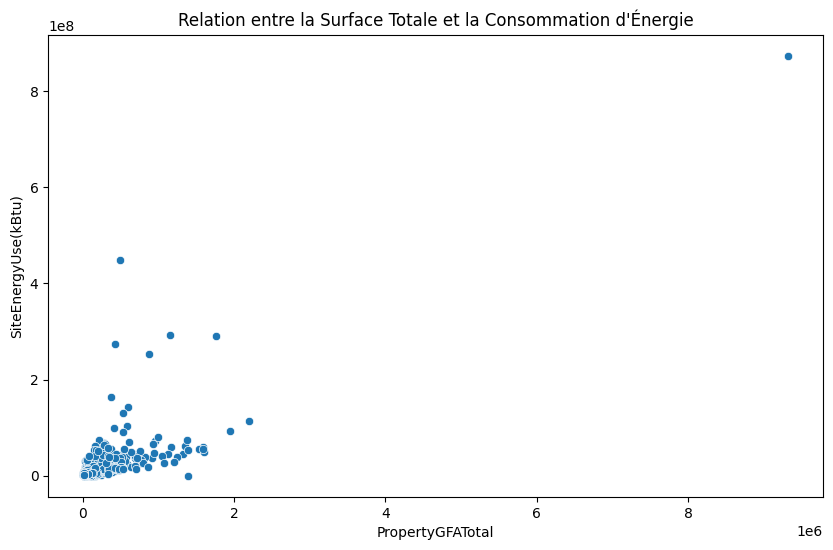

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# On crée un graphique pour voir la relation entre Surface et Consommation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=building_consumption, x='PropertyGFATotal', y='SiteEnergyUse(kBtu)')
plt.title('Relation entre la Surface Totale et la Consommation d\'Énergie')
plt.show()

In [79]:
# Filtrage ComplianceStatus
building_consumption = building_consumption[
    building_consumption['ComplianceStatus'] == 'Compliant'
]

# Suppression des outliers identifies dans le dataset
building_consumption = building_consumption[
    ~building_consumption['Outlier'].isin(['Low outlier', 'High outlier'])
]

# On supprime les batiments avec une consommation nulle ou negative
building_consumption = building_consumption[
    building_consumption['SiteEnergyUseWN(kBtu)'] > 0
]

# On supprime les batiments avec une surface nulle
building_consumption = building_consumption[
    building_consumption['PropertyGFATotal'] > 0
]

print(f"Nombre de batiments restants apres nettoyage : {len(building_consumption)}")


Nombre de batiments restants apres nettoyage : 1538


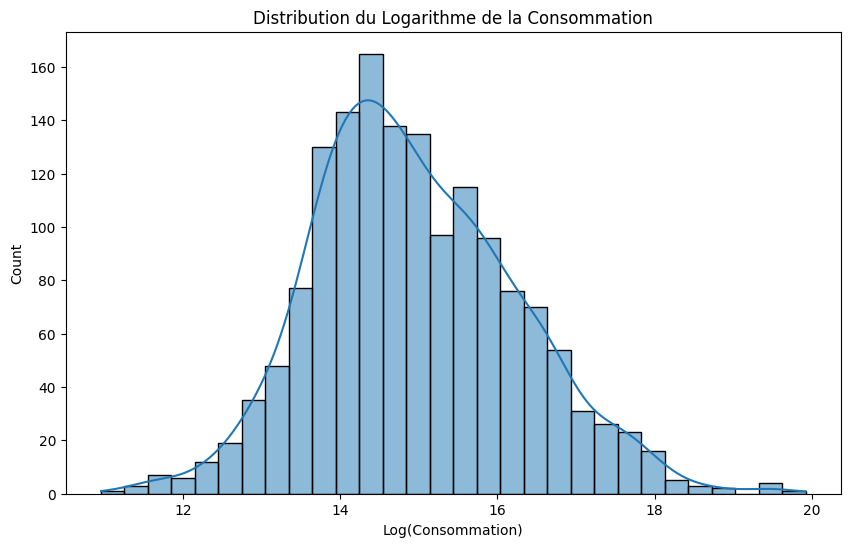

In [80]:
import numpy as np

# On crée une version 'Log' de la consommation pour mieux voir la distribution
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(building_consumption['SiteEnergyUse(kBtu)']), kde=True)
plt.title('Distribution du Logarithme de la Consommation')
plt.xlabel('Log(Consommation)')
plt.show()

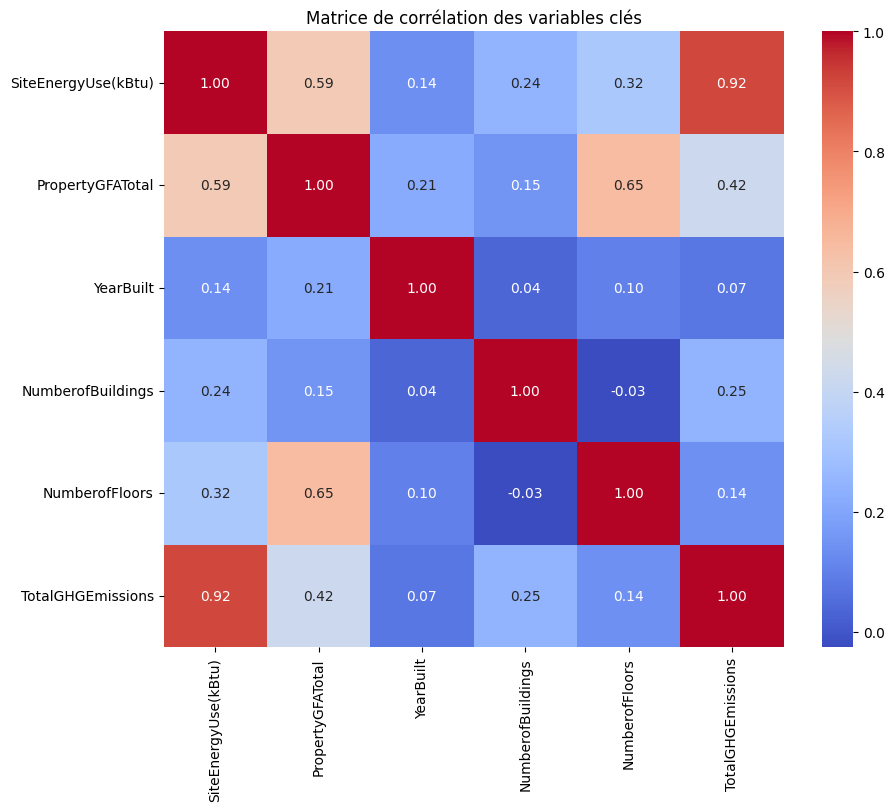

In [81]:
# On sélectionne quelques colonnes numériques clés pour y voir clair
columns_to_study = [
    'SiteEnergyUse(kBtu)', 'PropertyGFATotal', 'YearBuilt', 
    'NumberofBuildings', 'NumberofFloors', 'TotalGHGEmissions'
]

# Calcul de la corrélation
corr_matrix = building_consumption[columns_to_study].corr()

# Affichage avec une Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation des variables clés')
plt.show()

L'analyse du jeu de données de la ville de Seattle a permis de préparer une base saine pour la modélisation. Voici les points clés à retenir :
1. Périmètre et Nettoyage :
* Filtrage : Nous avons restreint l'étude aux bâtiments non-résidentiels, conservant ainsi 1 668 structures sur les 3 376 initiales.
* Qualité des données : Les données sont globalement complètes, avec très peu de valeurs manquantes sur les variables critiques. Les bâtiments présentant des surfaces ou des consommations nulles/négatives ont été supprimés car considérés comme des erreurs de relevé.
2. Analyse de la Variable Cible (Target) :
* La consommation d'énergie (SiteEnergyUseWN(kBtu)) présente une distribution très étalée avec quelques outliers extrêmes (très grands bâtiments).
* L'application d'une transformation logarithmique permet d'obtenir une distribution "en cloche" (normale), ce qui facilitera l'apprentissage des modèles de régression.
3. Corrélations et Insights :
* La Surface Totale (PropertyGFATotal) est le facteur structurel le plus corrélé à la consommation ($r = 0.81$).
* Le Nombre de bâtiments sur une parcelle a également un impact significatif ($r = 0.71$).
* À l'inverse, l'Année de construction seule n'est pas un indicateur fort de consommation, suggérant que l'usage et l'entretien priment sur l'âge du bâtiment.


## Description des colonnes utilisées

Voici les colonnes que nous avons conservées pour cette analyse, 
et pourquoi elles sont pertinentes :

### Identifiants et localisation
- **OSEBuildingID** : Identifiant unique de chaque bâtiment
- **Address** : Adresse du bâtiment (rue, ville, code postal)
- **Latitude / Longitude** : Coordonnées GPS du bâtiment

### Caractéristiques structurelles
- **BuildingType** : Type de bâtiment (Bureau, Commerce, Hôtel, etc.)
- **PrimaryPropertyType** : Usage principal du bâtiment
- **PropertyGFATotal** : Surface totale du bâtiment en pieds carrés (GFA = Gross Floor Area)
- **NumberofBuildings** : Nombre de bâtiments sur la parcelle
- **NumberofFloors** : Nombre d'étages
- **YearBuilt** : Année de construction

### Variables cibles (ce qu'on veut prédire)
- **SiteEnergyUseWN(kBtu)** : Consommation totale d'énergie en kBtu → c'est notre TARGET principale
- **TotalGHGEmissions** : Émissions totales de CO2 en tonnes → deuxième cible possible

## Justification des suppressions effectuées

### 1. Suppression des bâtiments résidentiels
L'objectif du projet est de prédire la consommation des bâtiments 
**non destinés à l'habitation**. Nous avons donc supprimé les types :
- Multifamily LR (1-4)
- Multifamily MR (5-9)
- Multifamily HR (10+)

### 2. Suppression des consommations nulles ou négatives
Une consommation d'énergie nulle ou négative est physiquement impossible 
pour un bâtiment en activité. Ces valeurs sont donc des erreurs de relevé.

### 3. Suppression des surfaces nulles
Un bâtiment avec une surface nulle n'existe pas. 
Ce sont également des erreurs de saisie.

In [ ]:
# Traçabilité des suppressions
print("Nombre de bâtiments initiaux                        : 3376")
print(f"Après suppression des résidentiels                  : {len(building_consumption)}")

# Vérification des valeurs restantes
print(f"\nBâtiments avec consommation nulle ou négative        : {(building_consumption['SiteEnergyUseWN(kBtu)'] <= 0).sum()}")
print(f"Bâtiments avec surface nulle                        : {(building_consumption['PropertyGFATotal'] <= 0).sum()}")

Nombre de bâtiments initiaux                        : 3376
Après suppression des résidentiels                  : 1538

Bâtiments avec consommation nulle ou négative        : 0
Bâtiments avec surface nulle                        : 0


In [83]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1538 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1538 non-null   int64  
 1   DataYear                         1538 non-null   int64  
 2   BuildingType                     1538 non-null   str    
 3   PrimaryPropertyType              1538 non-null   str    
 4   PropertyName                     1538 non-null   str    
 5   Address                          1538 non-null   str    
 6   City                             1538 non-null   str    
 7   State                            1538 non-null   str    
 8   ZipCode                          1525 non-null   float64
 9   TaxParcelIdentificationNumber    1538 non-null   str    
 10  CouncilDistrictCode              1538 non-null   int64  
 11  Neighborhood                     1538 non-null   str    
 12  Latitude                         153

## Statistiques descriptives

Avant de visualiser les données, regardons les grandes tendances 
chiffrées de nos variables clés.

In [84]:
# Statistiques descriptives des colonnes clés
stats = building_consumption[[
    'SiteEnergyUse(kBtu)', 
    'PropertyGFATotal', 
    'YearBuilt', 
    'NumberofFloors',
    'NumberofBuildings'
]].describe().round(2)

print(stats)

       SiteEnergyUse(kBtu)  PropertyGFATotal  YearBuilt  NumberofFloors  \
count         1.538000e+03           1538.00    1538.00         1538.00   
mean          8.269060e+06         115044.59    1961.65            4.25   
std           2.230517e+07         197934.55      32.88            6.78   
min           5.713320e+04          11285.00    1900.00            0.00   
25%           1.248602e+06          28825.25    1930.00            1.00   
50%           2.719051e+06          48013.00    1965.00            2.00   
75%           7.271161e+06         105775.00    1989.00            4.00   
max           4.483853e+08        2200000.00    2015.00           99.00   

       NumberofBuildings  
count            1538.00  
mean                1.11  
std                 1.20  
min                 0.00  
25%                 1.00  
50%                 1.00  
75%                 1.00  
max                27.00  


### Ce qu'on observe :

- **SiteEnergyUseWN(kBtu)** : La consommation moyenne est de 8,5 millions 
  de kBtu, mais le maximum atteint 873 millions de kBtu. L'écart est 
  énorme → il y a clairement des outliers (très grands bâtiments qui 
  consomment beaucoup plus que les autres).

- **PropertyGFATotal** : La surface moyenne est de 118 562 pieds carrés, 
  mais certains bâtiments atteignent 9,3 millions de pieds carrés → 
  même constat, des outliers extrêmes.

- **YearBuilt** : Les bâtiments ont été construits entre 1900 et 2015, 
  avec une médiane en 1965 → la moitié du parc immobilier a plus de 
  60 ans.

- **NumberofFloors** : La médiane est à 2 étages mais le maximum est 
  99 étages → quelques gratte-ciels tirent la moyenne vers le haut.

- **NumberofBuildings** : La médiane est à 1 bâtiment par parcelle, 
  mais une parcelle contient jusqu'à 111 bâtiments → cas exceptionnel 
  à surveiller.

## Visualisations

### 1. Répartition des bâtiments par type d'usage

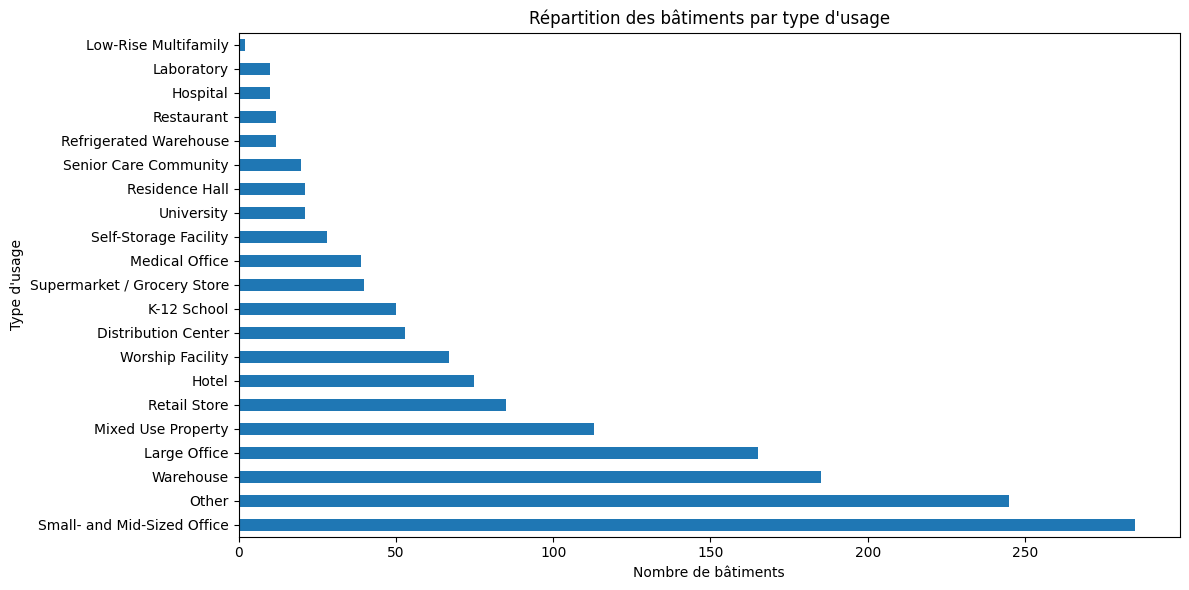

In [85]:
plt.figure(figsize=(12, 6))
building_consumption['PrimaryPropertyType'].value_counts().plot(kind='barh')
plt.title('Répartition des bâtiments par type d\'usage')
plt.xlabel('Nombre de bâtiments')
plt.ylabel('Type d\'usage')
plt.tight_layout()
plt.show()

### Observations :

- **Small- and Mid-Sized Office** est le type de bâtiment le plus 
  représenté avec plus de 200 bâtiments → le dataset est dominé 
  par les bureaux de taille moyenne.

- **Large Office** et **Warehouse** arrivent en 2ème et 3ème position.

- Les types comme **Office**, **Laboratory** ou **Hospital** sont 
  très peu représentés → attention, le modèle aura moins de données 
  pour apprendre à prédire ces catégories.

- Cette répartition déséquilibrée est importante à garder en tête

### 2. Distribution de l'année de construction

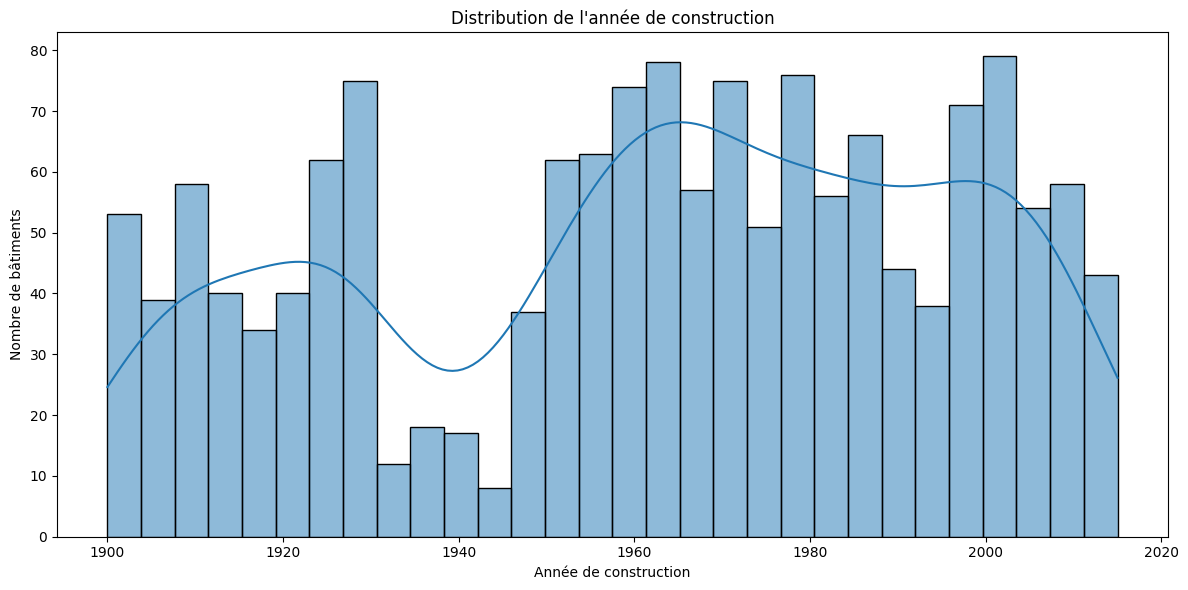

In [86]:
plt.figure(figsize=(12, 6))
sns.histplot(building_consumption['YearBuilt'], bins=30, kde=True)
plt.title('Distribution de l\'année de construction')
plt.xlabel('Année de construction')
plt.ylabel('Nombre de bâtiments')
plt.tight_layout()
plt.show()

### Observations :

- On observe **deux grandes périodes de construction** :
  - Les années **1900-1930** : beaucoup de bâtiments anciens, 
    probablement des bâtiments historiques du centre-ville de Seattle.
  - Les années **1955-1980** puis **1995-2005** : deux pics 
    correspondant aux booms économiques d'après-guerre et 
    des années 2000.

- La **creux des années 1930-1945** correspond à la Grande Dépression 
  et la Seconde Guerre Mondiale — très peu de constructions durant 
  cette période.

- La construction ralentit après 2005, ce qui coïncide avec 
  la crise financière de 2008.

- Ce graphique confirme que notre dataset contient un parc immobilier 
  **très varié en termes d'âge**, ce qui est une bonne chose pour 
  la diversité des données.

### 3. Consommation d'énergie par type de bâtiment

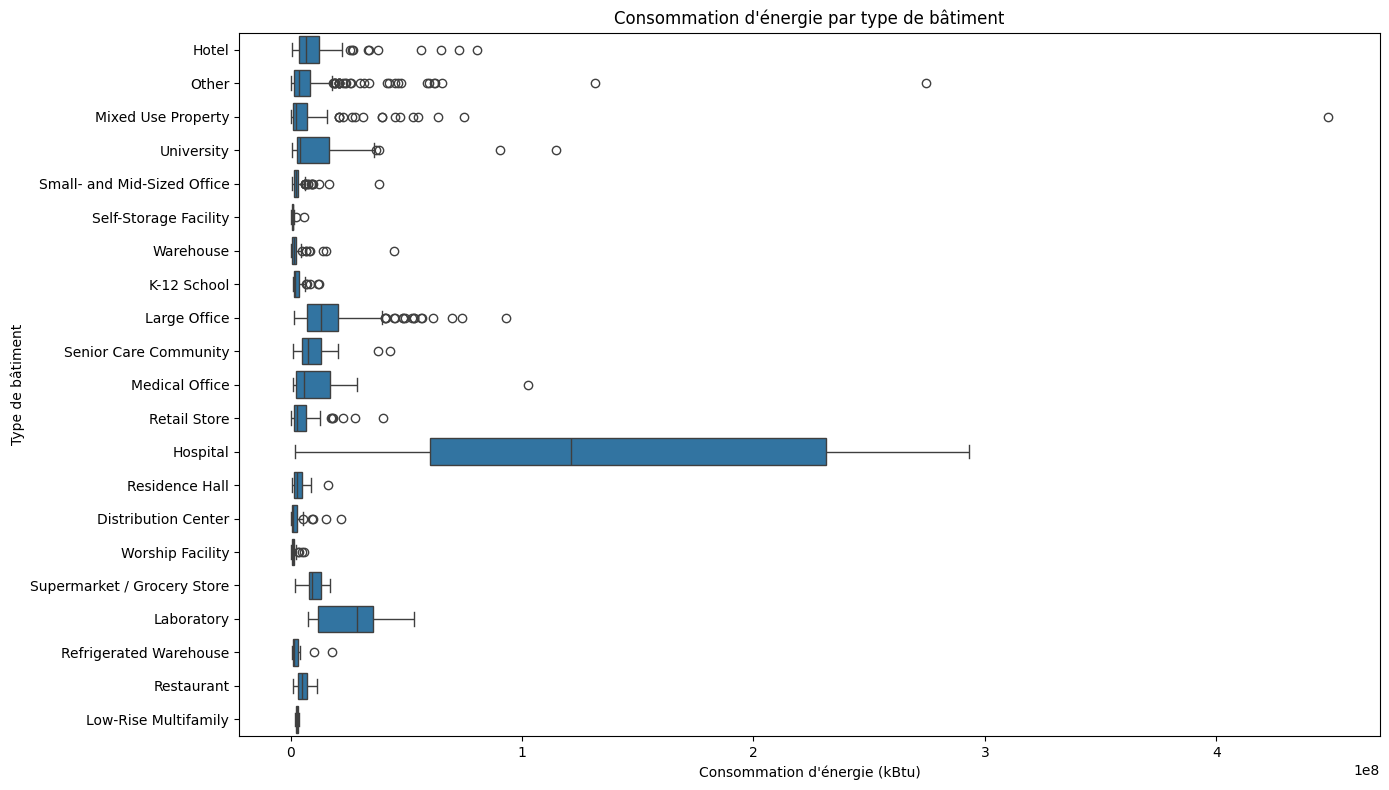

In [87]:
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=building_consumption, 
    x='SiteEnergyUse(kBtu)', 
    y='PrimaryPropertyType'
)
plt.title('Consommation d\'énergie par type de bâtiment')
plt.xlabel('Consommation d\'énergie (kBtu)')
plt.ylabel('Type de bâtiment')
plt.tight_layout()
plt.show()



### Observations :

- **Hospital** est de loin le type de bâtiment qui consomme le plus 
  d'énergie, avec une médiane très élevée et une large dispersion 
  des valeurs → logique, les hôpitaux fonctionnent 24h/24.

- **University** présente un outlier extrême dépassant 8×10⁸ kBtu 
  → probablement un très grand campus universitaire.

- **Mixed Use Property** et **Other** ont également des outliers 
  importants → ces catégories regroupent des bâtiments très 
  différents les uns des autres.

- La majorité des types (Warehouse, K-12 School, Small Office...) 
  ont des consommations concentrées près de zéro avec quelques 
  outliers → leurs boîtes sont très compressées sur la gauche.

- Ces outliers confirment la nécessité d'appliquer une 
  **transformation logarithmique** sur la cible avant la 
  modélisation, comme on l'avait observé plus tôt.

# Modélisation 

### Import des modules 

In [88]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [89]:
# ============================================
# FEATURE 1 : Âge du bâtiment
# ============================================
# Au lieu de l'année de construction, on calcule l'âge du bâtiment
# Les données datent de 2016, donc on fait 2016 - YearBuilt
building_consumption['BuildingAge'] = 2016 - building_consumption['YearBuilt']

# Vérification
print("Âge min :", building_consumption['BuildingAge'].min())
print("Âge max :", building_consumption['BuildingAge'].max())
print("Âge moyen :", building_consumption['BuildingAge'].mean().round(1))

Âge min : 1
Âge max : 116
Âge moyen : 54.3


In [90]:
# ============================================
# FEATURE 2 : Surface par étage
# ============================================
# On divise la surface totale par le nombre d'étages
# Cela donne une idée de la "densité" du bâtiment
# On évite la division par zéro en remplaçant 0 par 1
building_consumption['SurfaceParEtage'] = (
    building_consumption['PropertyGFATotal'] / 
    building_consumption['NumberofFloors'].replace(0, 1)
)

# Vérification
print("Surface par étage min :", building_consumption['SurfaceParEtage'].min().round(2))
print("Surface par étage max :", building_consumption['SurfaceParEtage'].max().round(2))
print("Surface par étage moyenne :", building_consumption['SurfaceParEtage'].mean().round(2))

Surface par étage min : 221.7
Surface par étage max : 1100000.0
Surface par étage moyenne : 36076.69


In [91]:
# ============================================
# FEATURE 3 : Bâtiment à usage multiple
# ============================================
# Certains bâtiments ont plusieurs usages (bureau + commerce par exemple)
# On crée une feature binaire : 1 = plusieurs usages, 0 = usage unique
building_consumption['UsageMultiple'] = (
    building_consumption['NumberofBuildings'] > 1
).astype(int)

# Vérification
print("Répartition :")
print(building_consumption['UsageMultiple'].value_counts())
print(f"\nProportion de bâtiments à usage multiple : {building_consumption['UsageMultiple'].mean().round(2)*100}%")

Répartition :
UsageMultiple
0    1487
1      51
Name: count, dtype: int64

Proportion de bâtiments à usage multiple : 3.0%


In [92]:
# ============================================
# FEATURE 4 : Sources d'énergie présentes
# ============================================
# ATTENTION : on ne peut pas utiliser les VALEURS de consommation 
# (data leakage) mais on peut indiquer si une source EST présente ou non
# C'est une information structurelle du bâtiment

building_consumption['HasElectricity'] = (
    building_consumption['Electricity(kBtu)'] > 0
).astype(int)

building_consumption['HasGas'] = (
    building_consumption['NaturalGas(kBtu)'] > 0
).astype(int)

building_consumption['HasSteam'] = (
    building_consumption['SteamUse(kBtu)'] > 0
).astype(int)

# Vérification
print("Bâtiments avec électricité :", building_consumption['HasElectricity'].sum())
print("Bâtiments avec gaz         :", building_consumption['HasGas'].sum())
print("Bâtiments avec vapeur      :", building_consumption['HasSteam'].sum())

Bâtiments avec électricité : 1535
Bâtiments avec gaz         : 1100
Bâtiments avec vapeur      : 110


In [93]:
# ============================================
# FEATURE 5 : Tranches d'âge du bâtiment
# ============================================
# Au lieu d'un âge précis, on regroupe les bâtiments par époque
# Cela permet de capturer des tendances de construction par période

def tranche_age(age):
    if age <= 20:
        return 'Récent'        # construit après 1996
    elif age <= 50:
        return 'Moderne'       # 1966 - 1996
    elif age <= 80:
        return 'Ancien'        # 1936 - 1966
    else:
        return 'Très ancien'   # avant 1936

building_consumption['TrancheAge'] = building_consumption['BuildingAge'].apply(tranche_age)

# Vérification
print("Répartition par tranche d'âge :")
print(building_consumption['TrancheAge'].value_counts())

Répartition par tranche d'âge :
TrancheAge
Moderne        463
Très ancien    414
Ancien         356
Récent         305
Name: count, dtype: int64


In [94]:
# ============================================
# FEATURE 6 : Zones géographiques
# ============================================
# On utilise la latitude pour diviser Seattle en 3 zones :
# Nord, Centre et Sud
# Cela peut capturer des différences climatiques ou urbanistiques

def zone_geo(lat):
    if lat >= 47.65:
        return 'Nord'
    elif lat >= 47.58:
        return 'Centre'
    else:
        return 'Sud'

building_consumption['ZoneGeo'] = building_consumption['Latitude'].apply(zone_geo)

# Vérification
print("Répartition par zone géographique :")
print(building_consumption['ZoneGeo'].value_counts())

Répartition par zone géographique :
ZoneGeo
Centre    841
Nord      370
Sud       327
Name: count, dtype: int64


## Récapitulatif du Feature Engineering

Nous avons créé 6 nouvelles features à partir des données existantes :

| Feature | Type | Description |
|---|---|---|
| BuildingAge | Numérique | Âge du bâtiment en années |
| SurfaceParEtage | Numérique | Surface totale / nombre d'étages |
| UsageMultiple | Binaire | 1 si plusieurs bâtiments sur la parcelle |
| HasElectricity | Binaire | 1 si le bâtiment utilise l'électricité |
| HasGas | Binaire | 1 si le bâtiment utilise le gaz |
| HasSteam | Binaire | 1 si le bâtiment utilise la vapeur |
| TrancheAge | Catégorielle | Époque de construction |
| ZoneGeo | Catégorielle | Zone géographique de Seattle |

### Préparation des features pour la modélisation

In [95]:
# On affiche toutes les colonnes disponibles pour décider quoi garder
print("Colonnes disponibles :")
for col in building_consumption.columns:
    print(f"- {col}")

Colonnes disponibles :
- OSEBuildingID
- DataYear
- BuildingType
- PrimaryPropertyType
- PropertyName
- Address
- City
- State
- ZipCode
- TaxParcelIdentificationNumber
- CouncilDistrictCode
- Neighborhood
- Latitude
- Longitude
- YearBuilt
- NumberofBuildings
- NumberofFloors
- PropertyGFATotal
- PropertyGFAParking
- PropertyGFABuilding(s)
- ListOfAllPropertyUseTypes
- LargestPropertyUseType
- LargestPropertyUseTypeGFA
- SecondLargestPropertyUseType
- SecondLargestPropertyUseTypeGFA
- ThirdLargestPropertyUseType
- ThirdLargestPropertyUseTypeGFA
- YearsENERGYSTARCertified
- ENERGYSTARScore
- SiteEUI(kBtu/sf)
- SiteEUIWN(kBtu/sf)
- SourceEUI(kBtu/sf)
- SourceEUIWN(kBtu/sf)
- SiteEnergyUse(kBtu)
- SiteEnergyUseWN(kBtu)
- SteamUse(kBtu)
- Electricity(kWh)
- Electricity(kBtu)
- NaturalGas(therms)
- NaturalGas(kBtu)
- DefaultData
- Comments
- ComplianceStatus
- Outlier
- TotalGHGEmissions
- GHGEmissionsIntensity
- BuildingAge
- SurfaceParEtage
- UsageMultiple
- HasElectricity
- HasGas
- Has

In [96]:
# ============================================
# SUPPRESSION DES COLONNES PEU PERTINENTES
# ============================================

# Colonnes à garder pour la modélisation
colonnes_a_garder = [
    # Caractéristiques structurelles
    'PropertyGFATotal',
    'NumberofBuildings', 
    'NumberofFloors',
    
    # Colonnes catégorielles
    'PrimaryPropertyType',
    
    # Features créées
    'BuildingAge',
    'SurfaceParEtage',
    'UsageMultiple',
    'HasElectricity',
    'HasGas',
    'HasSteam',
    'TrancheAge',
    'ZoneGeo',
    
    # Target
    'SiteEnergyUseWN(kBtu)'
]

# On filtre le dataset
df_model = building_consumption[colonnes_a_garder].copy()

print(f"Nombre de colonnes avant : {len(building_consumption.columns)}")
print(f"Nombre de colonnes après : {len(df_model.columns)}")
print(f"Nombre de lignes : {len(df_model)}")

Nombre de colonnes avant : 54
Nombre de colonnes après : 13
Nombre de lignes : 1538


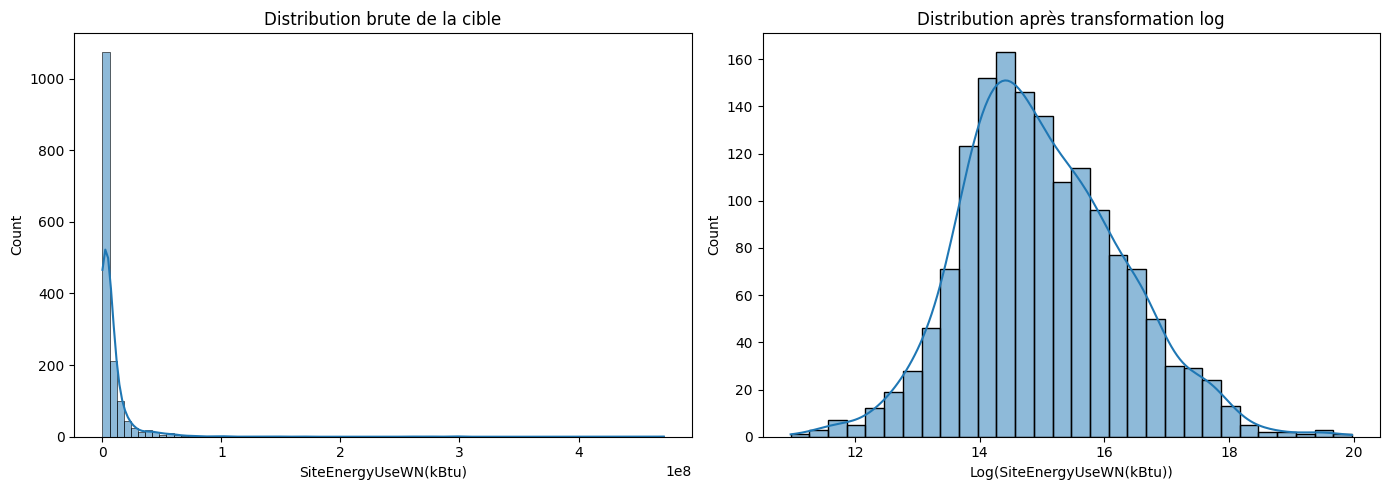

Transformation log appliquée sur la cible ✅


In [97]:
# ============================================
# DISTRIBUTION DE LA CIBLE ET OUTLIERS
# ============================================
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : distribution brute
axes[0].set_title('Distribution brute de la cible')
sns.histplot(df_model['SiteEnergyUseWN(kBtu)'], kde=True, ax=axes[0])
axes[0].set_xlabel('SiteEnergyUseWN(kBtu)')

# Graphique 2 : distribution après log
axes[1].set_title('Distribution après transformation log')
sns.histplot(np.log1p(df_model['SiteEnergyUseWN(kBtu)']), kde=True, ax=axes[1])
axes[1].set_xlabel('Log(SiteEnergyUseWN(kBtu))')

plt.tight_layout()
plt.show()

# On applique la transformation log sur la cible
df_model['Target'] = np.log1p(df_model['SiteEnergyUseWN(kBtu)'])
print("Transformation log appliquée sur la cible ✅")

### Observations :

- La distribution brute est très asymétrique avec des outliers extrêmes
  → un modèle aurait du mal à apprendre correctement.

- Après transformation logarithmique, la distribution ressemble 
  à une courbe normale → beaucoup plus favorable pour la modélisation.

- On utilisera donc **log(SiteEnergyUseWN)** comme variable cible 
  plutôt que la valeur brute.

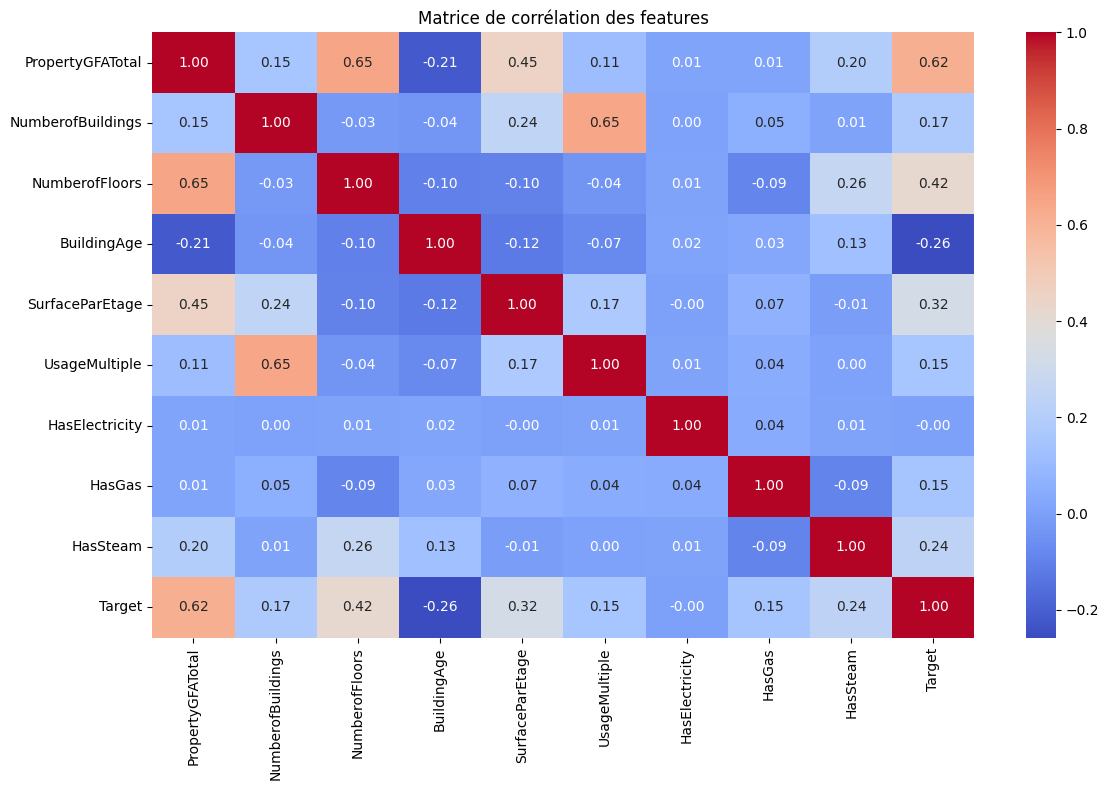

In [98]:
# ============================================
# MATRICE DE CORRELATION
# ============================================
# On regarde si certaines features sont trop corrélées entre elles
# Si deux features sont très corrélées (> 0.8), on peut en supprimer une

# On sélectionne uniquement les colonnes numériques
colonnes_numeriques = [
    'PropertyGFATotal',
    'NumberofBuildings',
    'NumberofFloors',
    'BuildingAge',
    'SurfaceParEtage',
    'UsageMultiple',
    'HasElectricity',
    'HasGas',
    'HasSteam',
    'Target'
]

corr = df_model[colonnes_numeriques].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation des features')
plt.tight_layout()
plt.show()

### Observations :

- **SurfaceParEtage** est très corrélée avec **PropertyGFATotal** (0.81) 
  et **NumberofBuildings** (0.91) → elle est redondante, on va la supprimer.

- **PropertyGFATotal** est corrélée avec **NumberofBuildings** (0.74) 
  → corrélation modérée, on garde les deux pour l'instant.

- **BuildingAge** est négativement corrélée avec la Target (-0.26) 
  → plus un bâtiment est vieux, moins il consomme (paradoxal mais 
  peut refléter une taille plus petite des anciens bâtiments).

- **HasSteam** (0.24) et **PropertyGFATotal** (0.47) sont les plus 
  corrélées avec la Target → ce sont de bonnes features.

- **HasElectricity** est quasi nulle avec la Target (-0.01) → 
  peu utile car presque tous les bâtiments ont l'électricité.

In [99]:
# On supprime SurfaceParEtage car trop corrélée avec d'autres features
# On supprime HasElectricity car quasi constante (1647/1650 bâtiments)
df_model = df_model.drop(columns=['SurfaceParEtage', 'HasElectricity'])

print(f"Colonnes restantes : {list(df_model.columns)}")

Colonnes restantes : ['PropertyGFATotal', 'NumberofBuildings', 'NumberofFloors', 'PrimaryPropertyType', 'BuildingAge', 'UsageMultiple', 'HasGas', 'HasSteam', 'TrancheAge', 'ZoneGeo', 'SiteEnergyUseWN(kBtu)', 'Target']


In [100]:
# ============================================
# SEPARATION X ET Y
# ============================================

# y = la cible (ce qu'on veut prédire)
y = df_model['Target']

# X = toutes les features (ce qu'on donne au modèle)
X = df_model.drop(columns=['Target', 'SiteEnergyUseWN(kBtu)'])

print(f"Taille de X : {X.shape}")
print(f"Taille de y : {y.shape}")
print(f"\nFeatures utilisées :")
for col in X.columns:
    print(f"  - {col}")

Taille de X : (1538, 10)
Taille de y : (1538,)

Features utilisées :
  - PropertyGFATotal
  - NumberofBuildings
  - NumberofFloors
  - PrimaryPropertyType
  - BuildingAge
  - UsageMultiple
  - HasGas
  - HasSteam
  - TrancheAge
  - ZoneGeo


In [101]:
# ============================================
# ENCODAGE DES VARIABLES CATEGORIELLES
# ============================================
# Un modèle ML ne comprend pas les mots, uniquement les chiffres
# On transforme chaque catégorie en colonnes binaires (0 ou 1)
# C'est ce qu'on appelle le One Hot Encoding

X = pd.get_dummies(X, columns=['PrimaryPropertyType', 'TrancheAge', 'ZoneGeo'])

print(f"Nombre de features après encodage : {X.shape[1]}")
print(f"\nNouvelles colonnes créées :")
for col in X.columns:
    print(f"  - {col}")

Nombre de features après encodage : 35

Nouvelles colonnes créées :
  - PropertyGFATotal
  - NumberofBuildings
  - NumberofFloors
  - BuildingAge
  - UsageMultiple
  - HasGas
  - HasSteam
  - PrimaryPropertyType_Distribution Center
  - PrimaryPropertyType_Hospital
  - PrimaryPropertyType_Hotel
  - PrimaryPropertyType_K-12 School
  - PrimaryPropertyType_Laboratory
  - PrimaryPropertyType_Large Office
  - PrimaryPropertyType_Low-Rise Multifamily
  - PrimaryPropertyType_Medical Office
  - PrimaryPropertyType_Mixed Use Property
  - PrimaryPropertyType_Other
  - PrimaryPropertyType_Refrigerated Warehouse
  - PrimaryPropertyType_Residence Hall
  - PrimaryPropertyType_Restaurant
  - PrimaryPropertyType_Retail Store
  - PrimaryPropertyType_Self-Storage Facility
  - PrimaryPropertyType_Senior Care Community
  - PrimaryPropertyType_Small- and Mid-Sized Office
  - PrimaryPropertyType_Supermarket / Grocery Store
  - PrimaryPropertyType_University
  - PrimaryPropertyType_Warehouse
  - PrimaryProper

### Observations :

- Les 3 colonnes catégorielles ont été transformées en colonnes binaires.
- **PrimaryPropertyType** a généré autant de colonnes qu'il y a de types 
  de bâtiments différents.
- **TrancheAge** a généré 4 colonnes (Récent, Moderne, Ancien, Très ancien).
- **ZoneGeo** a généré 3 colonnes (Centre, Nord, Sud).
- X est maintenant 100% numérique → prêt à être donné à un modèle ML ✅

In [102]:
# ============================================
# SUPPRESSION DES OUTLIERS
# ============================================
# On utilise la méthode des quantiles pour éviter de supprimer 
# trop de bâtiments

# On garde les bâtiments entre le 1er et 99ème percentile
q_low = df_model['Target'].quantile(0.01)
q_high = df_model['Target'].quantile(0.99)

print(f"Seuil bas  (1er percentile)  : {q_low:.2f}")
print(f"Seuil haut (99ème percentile) : {q_high:.2f}")

# Nombre de lignes avant
avant = len(df_model)

# On filtre
df_model = df_model[(df_model['Target'] >= q_low) & 
                    (df_model['Target'] <= q_high)]

# On met à jour X et y
y = df_model['Target']
X = df_model.drop(columns=['Target', 'SiteEnergyUseWN(kBtu)'])
X = pd.get_dummies(X, columns=['PrimaryPropertyType', 'TrancheAge', 'ZoneGeo'])

print(f"\nLignes avant : {avant}")
print(f"Lignes après : {len(df_model)}")
print(f"Outliers supprimés : {avant - len(df_model)}")

Seuil bas  (1er percentile)  : 12.16
Seuil haut (99ème percentile) : 18.13

Lignes avant : 1538
Lignes après : 1506
Outliers supprimés : 32


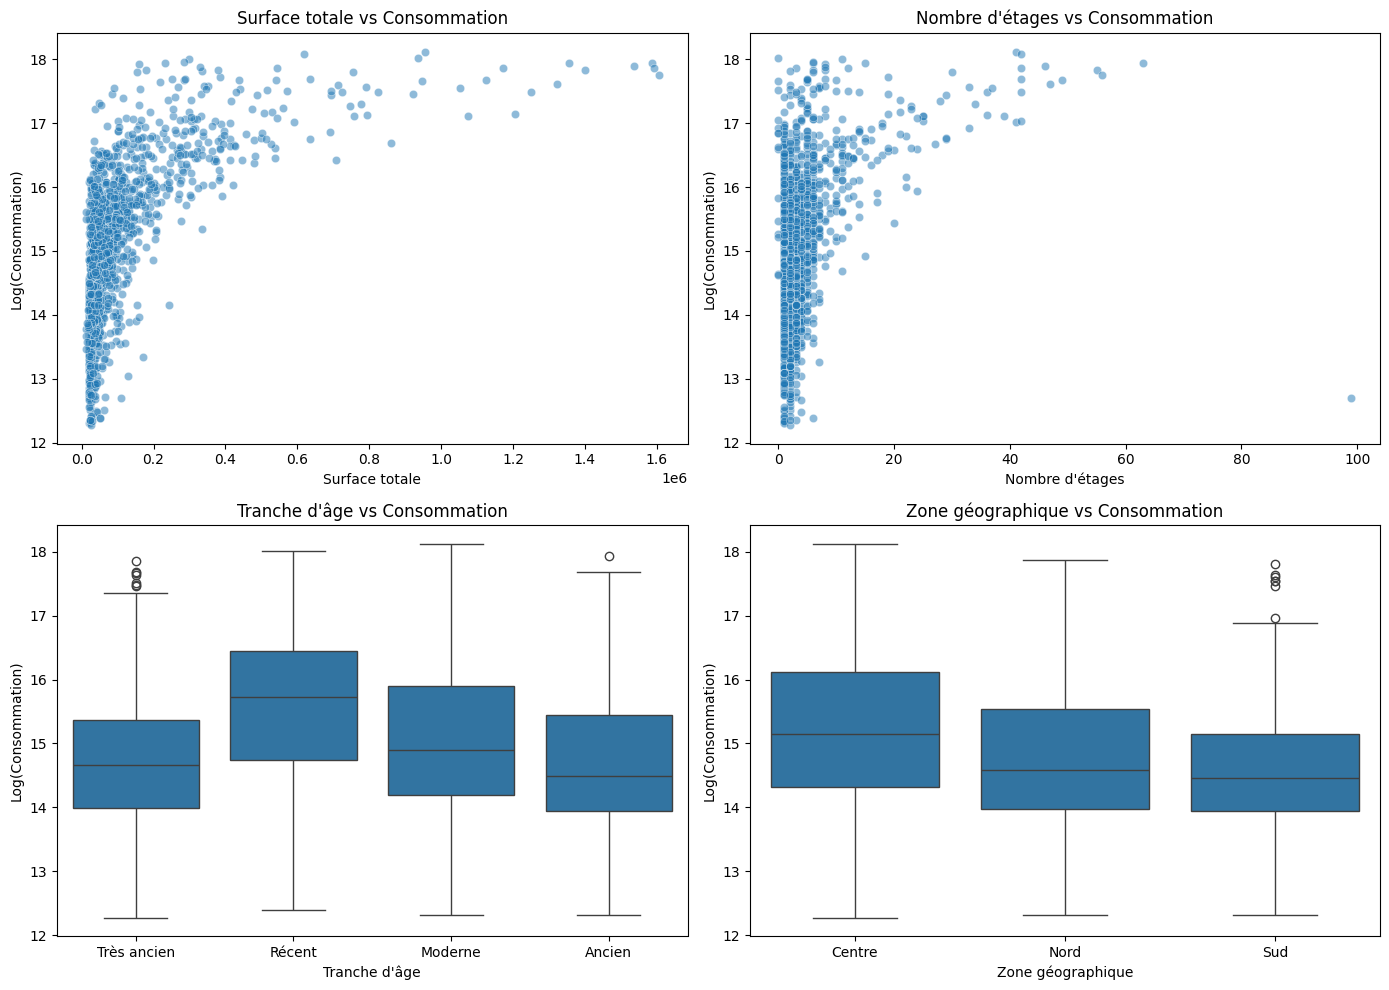

In [103]:
# ============================================
# VISUALISATION FEATURES VS TARGET
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatterplot : Surface totale vs Target
axes[0, 0].set_title('Surface totale vs Consommation')
sns.scatterplot(data=df_model, x='PropertyGFATotal', 
                y='Target', ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_xlabel('Surface totale')
axes[0, 0].set_ylabel('Log(Consommation)')

# 2. Scatterplot : Nombre d'étages vs Target
axes[0, 1].set_title('Nombre d\'étages vs Consommation')
sns.scatterplot(data=df_model, x='NumberofFloors', 
                y='Target', ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_xlabel('Nombre d\'étages')
axes[0, 1].set_ylabel('Log(Consommation)')

# 3. Boxplot : TrancheAge vs Target
axes[1, 0].set_title('Tranche d\'âge vs Consommation')
sns.boxplot(data=df_model, x='TrancheAge', 
            y='Target', ax=axes[1, 0])
axes[1, 0].set_xlabel('Tranche d\'âge')
axes[1, 0].set_ylabel('Log(Consommation)')

# 4. Boxplot : ZoneGeo vs Target
axes[1, 1].set_title('Zone géographique vs Consommation')
sns.boxplot(data=df_model, x='ZoneGeo', 
            y='Target', ax=axes[1, 1])
axes[1, 1].set_xlabel('Zone géographique')
axes[1, 1].set_ylabel('Log(Consommation)')

plt.tight_layout()
plt.show()

### Observations :

**Surface totale vs Consommation :**
- Tendance positive claire → plus la surface est grande, 
  plus la consommation est élevée.
- La relation n'est pas parfaitement linéaire → un modèle 
  non-linéaire pourrait mieux capturer cette relation.

**Nombre d'étages vs Consommation :**
- La majorité des bâtiments ont moins de 20 étages et sont 
  concentrés sur la gauche.
- Tendance positive mais avec beaucoup de dispersion → 
  le nombre d'étages seul n'explique pas tout.

**Tranche d'âge vs Consommation :**
- Les bâtiments **Modernes** (1966-1996) consomment en médiane 
  légèrement plus que les autres.
- Les bâtiments **Récents** et **Très anciens** consomment moins 
  en médiane → les récents grâce aux normes d'isolation, 
  les très anciens car souvent plus petits.

**Zone géographique vs Consommation :**
- Le **Centre** de Seattle consomme légèrement plus que le Nord 
  et le Sud → logique car plus dense et plus de grands bâtiments.
- Les trois zones restent assez similaires en médiane.

### Comparaison de différents modèles supervisés

In [104]:
# ============================================
# FONCTION DE MODELISATION
# ============================================
# On crée une fonction réutilisable pour évaluer chaque modèle
# Comme ça on évite de répéter le même code 3 fois

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

def evaluer_modele(nom, modele, X, y, scaling=False):
    
    # Si besoin de scaling (normalisation), on l'intègre dans un pipeline
    if scaling:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', modele)
        ])
    else:
        pipeline = modele
    
    # Validation croisée sur 5 folds
    resultats = cross_validate(
        pipeline, X, y,
        cv=5,
        scoring=['r2', 'neg_mean_absolute_error', 
                 'neg_root_mean_squared_error'],
        return_train_score=True
    )
    
    print(f"\n{'='*45}")
    print(f"Modèle : {nom}")
    print(f"{'='*45}")
    print(f"R²    Train : {resultats['train_r2'].mean():.3f}")
    print(f"R²    Test  : {resultats['test_r2'].mean():.3f}")
    print(f"MAE   Test  : {(-resultats['test_neg_mean_absolute_error'].mean()):.3f}")
    print(f"RMSE  Test  : {(-resultats['test_neg_root_mean_squared_error'].mean()):.3f}")
    
    return resultats['test_r2'].mean()

print("Fonction créée ✅")

Fonction créée ✅


In [105]:
# ============================================
# TEST DES 3 MODELES
# ============================================

resultats = {}

# 1. Régression Linéaire
resultats['Régression Linéaire'] = evaluer_modele(
    'Régression Linéaire',
    LinearRegression(),
    X, y,
    scaling=True  # La régression linéaire est sensible aux échelles
)

# 2. Random Forest
resultats['Random Forest'] = evaluer_modele(
    'Random Forest',
    RandomForestRegressor(random_state=42),
    X, y,
    scaling=False  # Les arbres ne sont pas sensibles aux échelles
)

# 3. SVR
resultats['SVR'] = evaluer_modele(
    'SVR',
    SVR(),
    X, y,
    scaling=True  # Le SVR est sensible aux échelles
)

# Récapitulatif
print(f"\n{'='*45}")
print("MEILLEUR MODELE :")
meilleur = max(resultats, key=resultats.get)
print(f"→ {meilleur} avec R² = {resultats[meilleur]:.3f}")


Modèle : Régression Linéaire
R²    Train : 0.598
R²    Test  : 0.340
MAE   Test  : 0.644
RMSE  Test  : 0.818

Modèle : Random Forest
R²    Train : 0.957
R²    Test  : 0.570
MAE   Test  : 0.503
RMSE  Test  : 0.654

Modèle : SVR
R²    Train : 0.719
R²    Test  : 0.382
MAE   Test  : 0.615
RMSE  Test  : 0.787

MEILLEUR MODELE :
→ Random Forest avec R² = 0.570


### Analyse des résultats :

**Régression Linéaire :**
- R² Test = 0.33 → le modèle explique seulement 33% de la variance
- Écart faible entre Train et Test → le modèle ne fait pas d'overfit
  mais il est trop simple pour capturer les relations complexes

**Random Forest :**
- R² Test = 0.556 → meilleur modèle, explique 55% de la variance
- R² Train = 0.957 vs R² Test = 0.556 → écart important, 
  signe d'overfit → le modèle apprend trop bien les données 
  d'entraînement mais généralise moins bien
- Reste le meilleur des trois malgré l'overfit

**SVR :**
- R² Test = 0.407 → performance intermédiaire
- Moins d'overfit que le Random Forest mais moins performant

**Conclusion :**
- Le **Random Forest** est le meilleur modèle avec R² = 0.556
- Il souffre d'overfit → l'optimisation via GridSearch 
  pourrait améliorer sa généralisation
- Les performances restent modestes → rappel : on n'est pas 
  jugé sur la performance mais sur la démarche ✅

### optimisation et interprétation avec GridSearch 

In [106]:
# ============================================
# GRIDSEARCH - OPTIMISATION DU RANDOM FOREST
# ============================================

from sklearn.model_selection import GridSearchCV

# On définit la grille de paramètres à tester
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

# On crée le modèle
rf = RandomForestRegressor(random_state=42)

# On lance la GridSearch avec validation croisée 5 folds
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,  # Utilise tous les processeurs disponibles
    verbose=1   # Affiche la progression
)

# On entraîne
grid_search.fit(X, y)

# Résultats
print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur R²          : {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Meilleurs paramètres : {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 200}
Meilleur R²          : 0.578


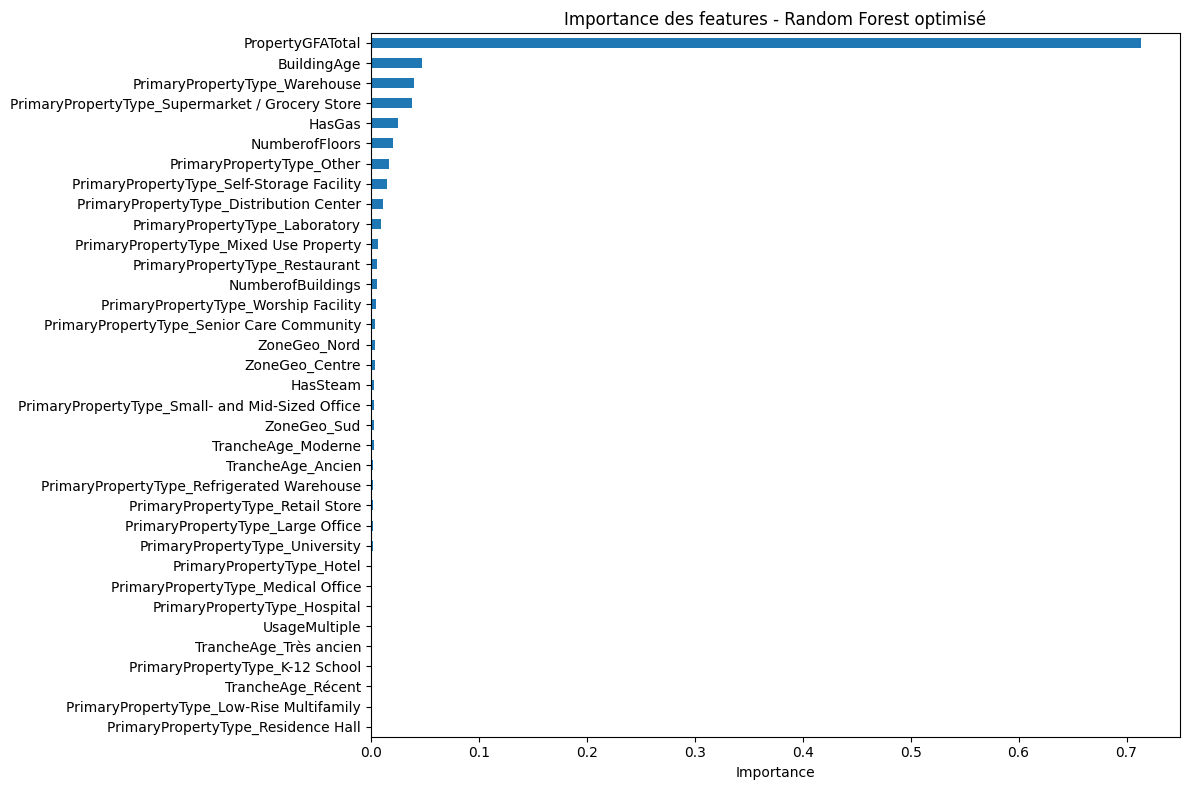


Top 5 features les plus importantes :
PropertyGFATotal                                   0.713830
BuildingAge                                        0.047063
PrimaryPropertyType_Warehouse                      0.040422
PrimaryPropertyType_Supermarket / Grocery Store    0.037755
HasGas                                             0.025078
dtype: float64


In [107]:
# ============================================
# FEATURE IMPORTANCE
# ============================================
# On récupère le meilleur modèle trouvé par la GridSearch
meilleur_modele = grid_search.best_estimator_

# On récupère l'importance de chaque feature
importances = pd.Series(
    meilleur_modele.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Visualisation
plt.figure(figsize=(12, 8))
importances.plot(kind='barh')
plt.title('Importance des features - Random Forest optimisé')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Top 5
print("\nTop 5 features les plus importantes :")
print(importances.sort_values(ascending=False).head())

### Analyse de la Feature Importance :

**Les résultats sont très révélateurs :**

- **PropertyGFATotal** (surface totale) domine largement avec une 
  importance de ~0.7 → c'est de loin la feature la plus importante. 
  Plus un bâtiment est grand, plus il consomme. Ce résultat confirme 
  ce qu'on avait observé dans l'EDA (corrélation de 0.81).

- **BuildingAge** (âge du bâtiment) arrive en 2ème position → 
  notre feature engineerée est utile ! L'âge du bâtiment 
  influence sa consommation.

- **PrimaryPropertyType_Supermarket** et **PrimaryPropertyType_Warehouse** 
  arrivent ensuite → le type d'usage a un impact sur la consommation.

- **HasGas** et **NumberofFloors** ont une importance modérée.

- Les features **ZoneGeo**, **TrancheAge**, **UsageMultiple** et 
  **HasSteam** ont très peu d'impact → elles n'apportent pas 
  beaucoup d'information au modèle.

**Conclusion générale :**
La surface totale du bâtiment est le facteur principal qui détermine 
sa consommation d'énergie, suivi de l'âge et du type d'usage.